In [1]:
import datetime as dt
import json
import math
import os
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from tqdm import tqdm


from utils_data_vis import *
from utils_graphs import *

plt.style.use("seaborn-v0_8-colorblind")

In [2]:
datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"
measures_folder = "measures/"
plots_folder = "plots/latex/"

# Horas críticas (Beiró & Gandica et al.)
HORA_CRITICA_NAT, HORA_CRITICA_9N, HORA_CRITICA_CH = "429624", "437037", "394717"
hour_window_nat, hour_window_9n, hour_window_ch = 1, 2, 2

limites = True

# Zona horaria local por movimiento (eje X en Unipartite / Epsilon)
TIMEZONE = {
    "nat": "America/Argentina/Buenos_Aires",
    "9n": "America/Argentina/Buenos_Aires",
    "ch": "Europe/Paris",
}
CITY_LABEL = {
    "nat": "Buenos Aires",
    "9n": "Buenos Aires",
    "ch": "Paris",
}
X_LABEL_YEAR = {"nat": 2019, "9n": 2019, "ch": 2015}


def hour_to_local(hour, manifestation):
    """Convierte hora Unix (en horas) UTC → datetime en zona local del movimiento."""
    return dt.datetime.fromtimestamp(int(hour) * 3600, tz=ZoneInfo("UTC")).astimezone(
        ZoneInfo(TIMEZONE[manifestation])
    )


def make_horas_a_fecha_local(manifestation):
    def horas_a_fecha(x_val, pos):
        return hour_to_local(x_val, manifestation).strftime("%d-%b %Hh")

    return horas_a_fecha


def local_xlabel(manifestation):
    return f"Date and hour (local, {CITY_LABEL[manifestation]}, {X_LABEL_YEAR[manifestation]})"


X_LIM_RELATIVE_CTW = {
    "nat": (-48, 46),
    "9n": (-54, 42),
    "ch": (-48, 36),
}
HORA_CRITICA = {
    "nat": HORA_CRITICA_NAT,
    "9n": HORA_CRITICA_9N,
    "ch": HORA_CRITICA_CH,
}


def xlim_relative_ctw(manifestation):
    """Límites del eje X (horas Unix) centrados en la CTW."""
    ctw = int(HORA_CRITICA[manifestation])
    lo, hi = X_LIM_RELATIVE_CTW[manifestation]
    return ctw + lo, ctw + hi


def apply_xlim_relative_ctw(ax, manifestation):
    ax.set_xlim(*xlim_relative_ctw(manifestation))


# Finding the Critical Time Window (CTW)

In [3]:
from matplotlib.ticker import MaxNLocator


def rolling_mean(series, window):
    s = pd.to_numeric(series, errors="coerce")
    return s.rolling(window=window, min_periods=1).mean()


def rolling_mean_centrada(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.rolling(window=3, center=True, min_periods=1).mean()


def plot_ma_if_exists(df, N, axes, ycol, label):
    if ycol is None or ycol not in df:
        return
    y_ma = rolling_mean(df[ycol], N)
    axes[0].plot(x, y_ma, marker=None, linewidth=1.8, label=f"{label} (MA{N})")

def find_col(df, candidates):
    for cand in candidates:
        for col in df.columns:
            if col.strip() == cand.strip():
                return col
    return None


## NAT

In [4]:
otras_horas_nat = [str(hor) for hor in range(429576, 429672)]
registros = []  # aquí acumulamos las filas (hora, clave_max)

for i in otras_horas_nat:
	source_path = f"graphs/nodes_hashtag/nat/{hour_window_nat}/{i}.gexf"
	out_path =  f"epsilon_sq/nat/{i}/{i}.edge"
	if not os.path.exists(f"epsilon_sq/nat/{i}/"):
		os.makedirs(f"epsilon_sq/nat/{i}/")
	gexf_a_edge(source_path, out_path)    
	# Diccionario y clave con máximo valor
	d = get_dict_hora_kt("nat", i, hour_window=hour_window_nat)
	clave_max = max(d, key=d.get) if d else None  # None si el dict está vacío

	# Guardar registro
	registros.append({"hora": i, "clave_max": clave_max})

# Construir DataFrame final (dos columnas)
df_max = pd.DataFrame(registros, columns=["hora", "clave_max"])
df_max.to_csv("epsilon_sq/nat/kts.csv")


  9%|▉         | 18/200 [00:00<00:00, 2989.29it/s]


### All

Calculando el anidamiento y modularidad de nat con criterio: b


100%|██████████| 260/260 [00:00<00:00, 803624.94it/s]
/tmp/ipykernel_196319/487711735.py:49: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x_val, pos: dt.datetime.utcfromtimestamp(x_val * 3600).strftime("%d-%b %Hh")))


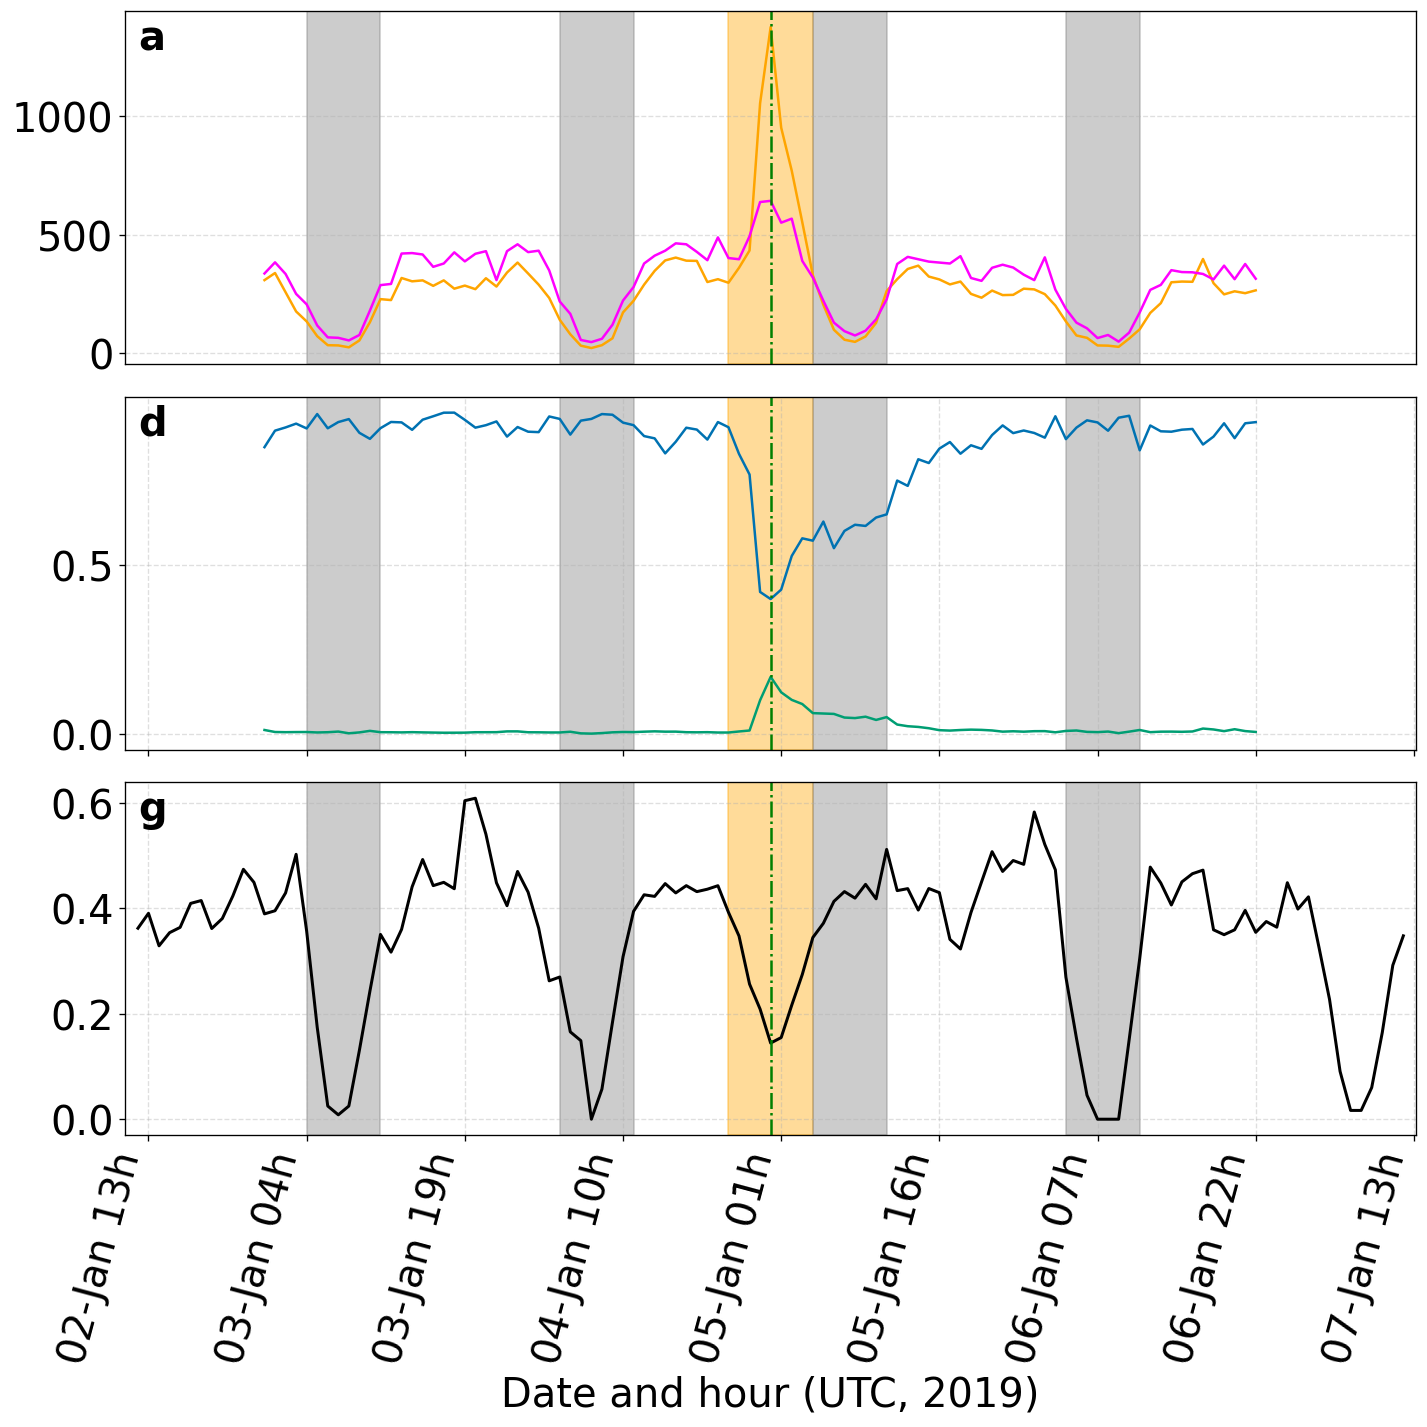

In [5]:
N = 3
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 12), dpi=120)

df = pd.read_csv("epsilon_sq/nat/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]
df_max = pd.read_csv("epsilon_sq/nat/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]

df = df.rename(
    columns={r"$\epsilon_{\ccdf}$": "eps_ccdf", r"$\epsilon_{\knn}$": "eps_knn", r"$\epsilon_{\cco}$": "eps_cco"}
)

network_col = find_col(df, ["Network", "network", "NETWORK"])
cco_col = find_col(df, ["eps_cco", r"$\epsilon_{\cco}$"])
if network_col is None:
    raise ValueError("Couldn't find 'Network' column in the file.")

labels = {"cco": r"$\epsilon_{\mathrm{cco}}$"}

x = df[network_col]
df_nat = read_data("nat", datasets_folder=datasets_folder)
hour_nat = np.sort(df_nat["hour"].unique())[::hour_window_nat]

num_users_nat, num_hashtags_nat = get_num_users_hashtags(df_nat, hour_window=hour_window_nat)
plot_num_users_hashtags(axes[0], hour_nat, hour_window_nat, num_users_nat, num_hashtags_nat, inicio=45, final=140, legend=False)

hour_sort_nat_b, mod_sort_nat_b, nest_sort_nat_b = get_mod_nest_coefficient(
    "nat", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat
)
plot_mod_nestedness(axes[1], hour_nat, hour_window_nat, mod_sort_nat_b, nest_sort_nat_b, inicio=45, final=140, legend=False, tick_split=30, HORA_CRITICA=None)

if cco_col is not None and cco_col in df:
    y_ma = rolling_mean_centrada(df[cco_col])
    axes[2].plot(x, y_ma, marker=None, linewidth=1.8, label=f"{labels['cco']} (MA{N})", c="black")

letras = ["a", "d", "g"]
for i, ax in enumerate(axes):
    ax.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green")
    ax.axvspan(429620, 429628, color="orange", alpha=0.4)
    ax.tick_params(axis="both", which="major", labelsize=24)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.margins(x=0.01)
    ax.axvspan(429580, 429587, color="gray", alpha=0.4)
    ax.axvspan(429604, 429611, color="gray", alpha=0.4)
    ax.axvspan(429628, 429635, color="gray", alpha=0.4)
    ax.axvspan(429652, 429659, color="gray", alpha=0.4)
    ax.text(0.01, 0.98, letras[i], transform=ax.transAxes, fontsize=24, fontweight="bold", va="top", ha="left")

axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x_val, pos: dt.datetime.utcfromtimestamp(x_val * 3600).strftime("%d-%b %Hh")))
axes[2].set_xlabel("Date and hour (UTC, 2019)", fontsize=24)
axes[2].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[2].get_xticklabels():
    tick.set_rotation(75)
    tick.set_ha("right")

plt.tight_layout()
plt.show()


### Unipartite

Calculando el anidamiento y modularidad de nat con criterio: h


100%|██████████| 260/260 [00:00<00:00, 1325053.51it/s]


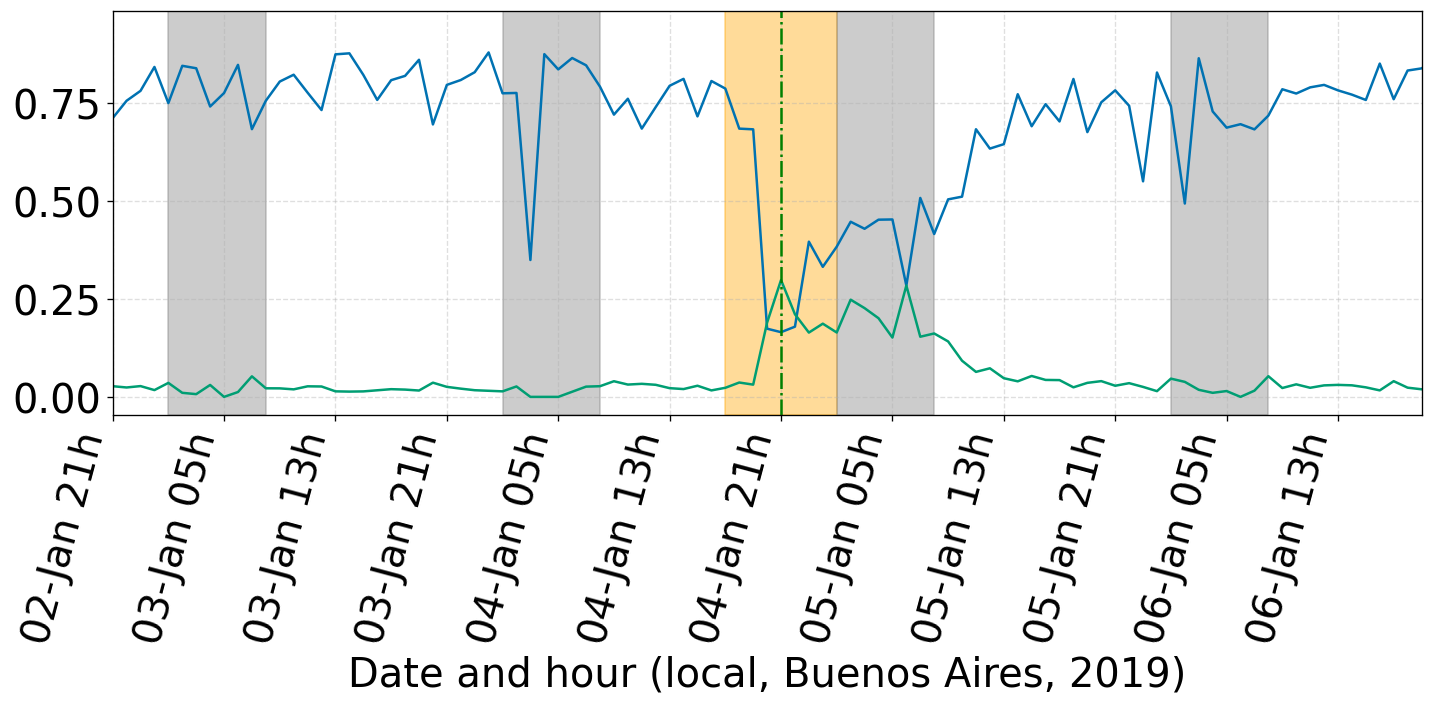

In [6]:

N = 3  # ventana de la media móvil (últimos N puntos)
fig, axes = plt.subplots(1, 1, sharex=True, figsize=(12, 6), dpi=120)

df = pd.read_csv("epsilon_sq/nat/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/nat/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

df = df.rename(columns={r"$\epsilon_{\ccdf}$": "eps_ccdf", r"$\epsilon_{\knn}$": "eps_knn", r"$\epsilon_{\cco}$": "eps_cco"})


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
	raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
	"ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
	"knn":  r"$\epsilon_{\mathrm{knn}}$",
	"cco":  r"$\epsilon_{\mathrm{cco}}$",
	"max":  r"$\epsilon_{max}$",
}

x = df[network_col]

df_nat = read_data("nat", datasets_folder=datasets_folder)

hour_nat = np.sort(df_nat["hour"].unique())[::hour_window_nat]


hour_sort_nat_h, mod_sort_nat_h, nest_sort_nat_h = get_mod_nest_coefficient("nat", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)
plot_mod_nestedness(axes, hour_nat, hour_window_nat, mod_sort_nat_h, nest_sort_nat_h, inicio=0, final=len(hour_nat)*hour_window_nat, legend=False, tick_split=30, HORA_CRITICA=None)



letras = ["a", "b", "c", "d"]
"""if i == 0:
	ax.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green", label=f"CTW No al Tarifazo\n{hour_to_local(int(HORA_CRITICA_NAT), 'nat').strftime('%Y/%m/%d %Hh')}")
else:
	ax.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green")"""
axes.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green")	 
#ax.axvspan(429620, 429628, color='orange', alpha=0.4, label="Candidates time windows")
axes.axvspan(429620, 429628, color='orange', alpha=0.4)
if i == 1:
	loc_legend="upper right"
else:
	loc_legend="center right"

#axes.legend(loc=loc_legend, fontsize=22)
axes.tick_params(axis='both', which='major', labelsize=24)  

axes.grid(True, linestyle="--", alpha=0.4)
axes.margins(x=0.01)
#from 00:01 to 8:00
#ax.axvspan(429580, 429587, color='gray', alpha=0.4, label="Low activity hours")
axes.axvspan(429580, 429587, color='gray', alpha=0.4)
axes.axvspan(429604, 429611, color='gray', alpha=0.4)
axes.axvspan(429628, 429635, color='gray', alpha=0.4)
axes.axvspan(429652, 429659, color='gray', alpha=0.4)

"""axes.text(
		0.01, 0.98, letras[i],            # posición (x,y) en coordenadas del eje
		transform=ax.transAxes,          # 0–1 relativo al eje
		fontsize=24,
		fontweight="bold",
		va="top",
		ha="left"
	)"""
#axes[0].set_title(f"No al tarifazo ε metrics by Network — Media móvil (N={N})")
#axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
#axes[2].set_title("Modularity and Nestedness (Hashtags)")
#axes[3].set_title("Modularity and Nestedness (Bipartite)")
#axes[3].set_xlabel("Date")


# Eje X en hora local (Buenos Aires)
horas_a_fecha = make_horas_a_fecha_local("nat")
axes.xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
axes.set_xlabel(local_xlabel("nat"), fontsize=24)
# Eje X menos cargado
axes.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes.get_xticklabels():
	tick.set_rotation(75)
	tick.set_ha("right")
# Límites X relativos a la CTW: −48 h … +46 h
apply_xlim_relative_ctw(axes, "nat")
plt.tight_layout()
plt.show()


### Epsilon

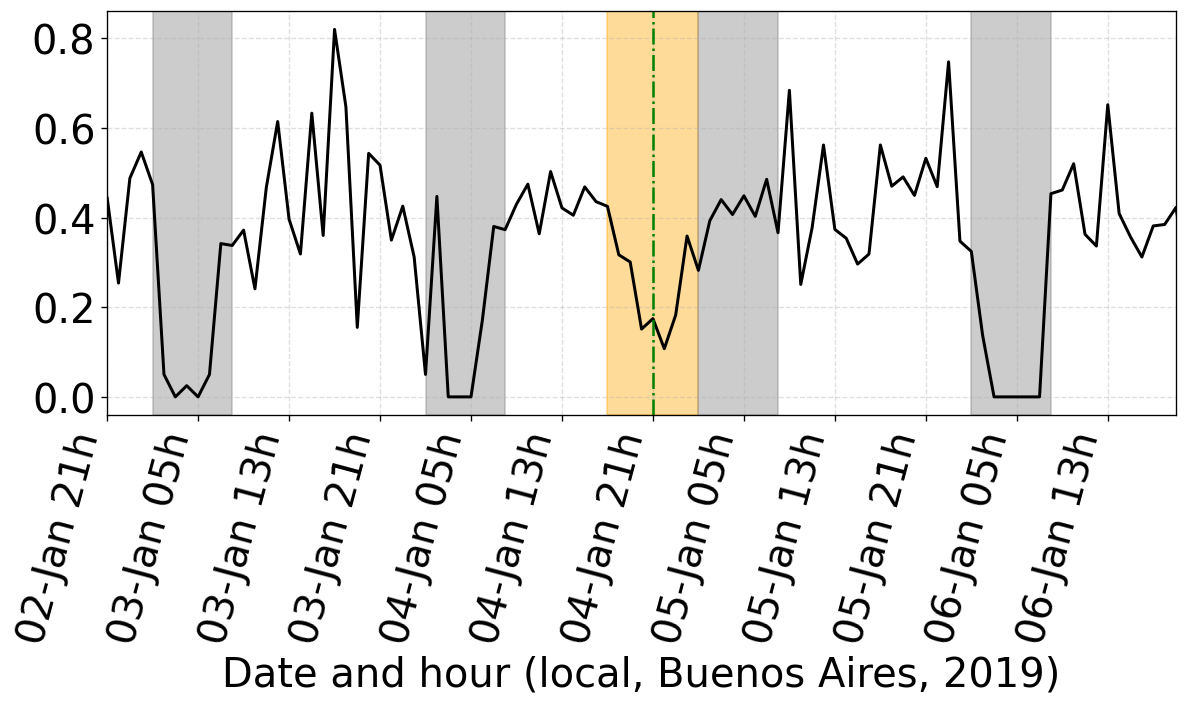

In [7]:

N = 1  # ventana de la media móvil (últimos N puntos)
fig, axes = plt.subplots(1, 1, sharex=True, figsize=(10, 6), dpi=120)
axes = [axes]
df = pd.read_csv("epsilon_sq/nat/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/nat/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

df = df.rename(columns={r"$\epsilon_{\ccdf}$": "eps_ccdf", r"$\epsilon_{\knn}$": "eps_knn", r"$\epsilon_{\cco}$": "eps_cco"})


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
    raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
    "ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
    "knn":  r"$\epsilon_{\mathrm{knn}}$",
    "cco":  r"$\epsilon_{\mathrm{cco}}$",
    "max":  r"$\epsilon_{max}$",
}

x = df[network_col]

df_nat = read_data("nat", datasets_folder=datasets_folder)

hour_nat = np.sort(df_nat["hour"].unique())[::hour_window_nat]


def plot_ma_if_exists(ycol, label):
	if ycol is not None and ycol in df:
		y_ma = rolling_mean(df[ycol], N)
		#y_ma = rolling_mean_centrada(df[ycol])
		axes[0].plot(
			x, y_ma,
			marker=None,            # no puntos: solo la media móvil
			linewidth=1.8,
			label=f"{label}",
            c="black"
		)
plot_ma_if_exists(cco_col, labels["cco"])

for i, ax in enumerate(axes):
	if i < 0:
		ax.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green", label=f"CTW No al Tarifazo\n{hour_to_local(int(HORA_CRITICA_NAT), 'nat').strftime('%Y/%m/%d %Hh')}")
	else:
	 	ax.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green")
		 
	ax.axvspan(429620, 429628, color='orange', alpha=0.4)
	#ax.axvspan(429620, 429628, color='orange', alpha=0.4, label="Candidates time windows")
	#ax.legend(loc="upper right", fontsize=22)
	
	ax.tick_params(axis='both', which='major', labelsize=24)  
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)
	#from 00:01 to 8:00
	ax.axvspan(429580, 429587, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(429604, 429611, color='gray', alpha=0.4)
	ax.axvspan(429628, 429635, color='gray', alpha=0.4)
	ax.axvspan(429652, 429659, color='gray', alpha=0.4)

#axes[0].set_title(f"No al tarifazo ε metrics by Network — Media móvil (N={N})")
#axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
#axes[1].set_title("Modularity and Nestedness (Bipartite)")
#axes[1].set_xlabel("Date")


# Eje X en hora local (Buenos Aires)
horas_a_fecha = make_horas_a_fecha_local("nat")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
axes[0].set_xlabel(local_xlabel("nat"), fontsize=24)
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[0].get_xticklabels():
    tick.set_rotation(75)
    tick.set_ha("right")



# Límites X relativos a la CTW: −48 h … +46 h
apply_xlim_relative_ctw(axes[0], "nat")
plt.tight_layout()
plt.show()


## 9N

In [8]:
otras_horas_9n = [str(hor) for hor in range(int(HORA_CRITICA_9N)-72, int(HORA_CRITICA_9N)+72)]
registros = []  # aquí acumulamos las filas (hora, clave_max)

for i in otras_horas_9n:
	source_path = f"graphs/nodes_hashtag/9n/{hour_window_9n}/{i}.gexf"
	out_path =  f"epsilon_sq/9n/{i}/{i}.edge"
	if not os.path.exists(f"./epsilon_sq/9n/{i}/"):
		os.makedirs(f"./epsilon_sq/9n/{i}/")
	if os.path.exists(source_path):
		gexf_a_edge(source_path, out_path)    
		# Diccionario y clave con máximo valor
		d = get_dict_hora_kt("9n", i, hour_window=hour_window_9n)
		clave_max = max(d, key=d.get) if d else None  # None si el dict está vacío

		# Guardar registro
		registros.append({"hora": i, "clave_max": clave_max})

# Construir DataFrame final (dos columnas)
df_max = pd.DataFrame(registros, columns=["hora", "clave_max"])
df_max.to_csv("./epsilon_sq/9n/kts.csv")


 58%|█████▊    | 116/200 [00:00<00:00, 965.76it/s]


Now we need to execute the script to compute epsilon values 

### All

Calculando el anidamiento y modularidad de 9n con criterio: h


100%|██████████| 49/49 [00:00<00:00, 736634.04it/s]


Calculando el anidamiento y modularidad de 9n con criterio: b


100%|██████████| 49/49 [00:00<00:00, 772634.95it/s]
/tmp/ipykernel_196319/826263050.py:69: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  ax.axvline(int(HORA_CRITICA_9N), linestyle="-.", color="green", label=f"CTW 9N\n{dt.datetime.utcfromtimestamp(int(HORA_CRITICA_9N)*3600).strftime('%Y/%m/%d %Hh')}")
/tmp/ipykernel_196319/826263050.py:108: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


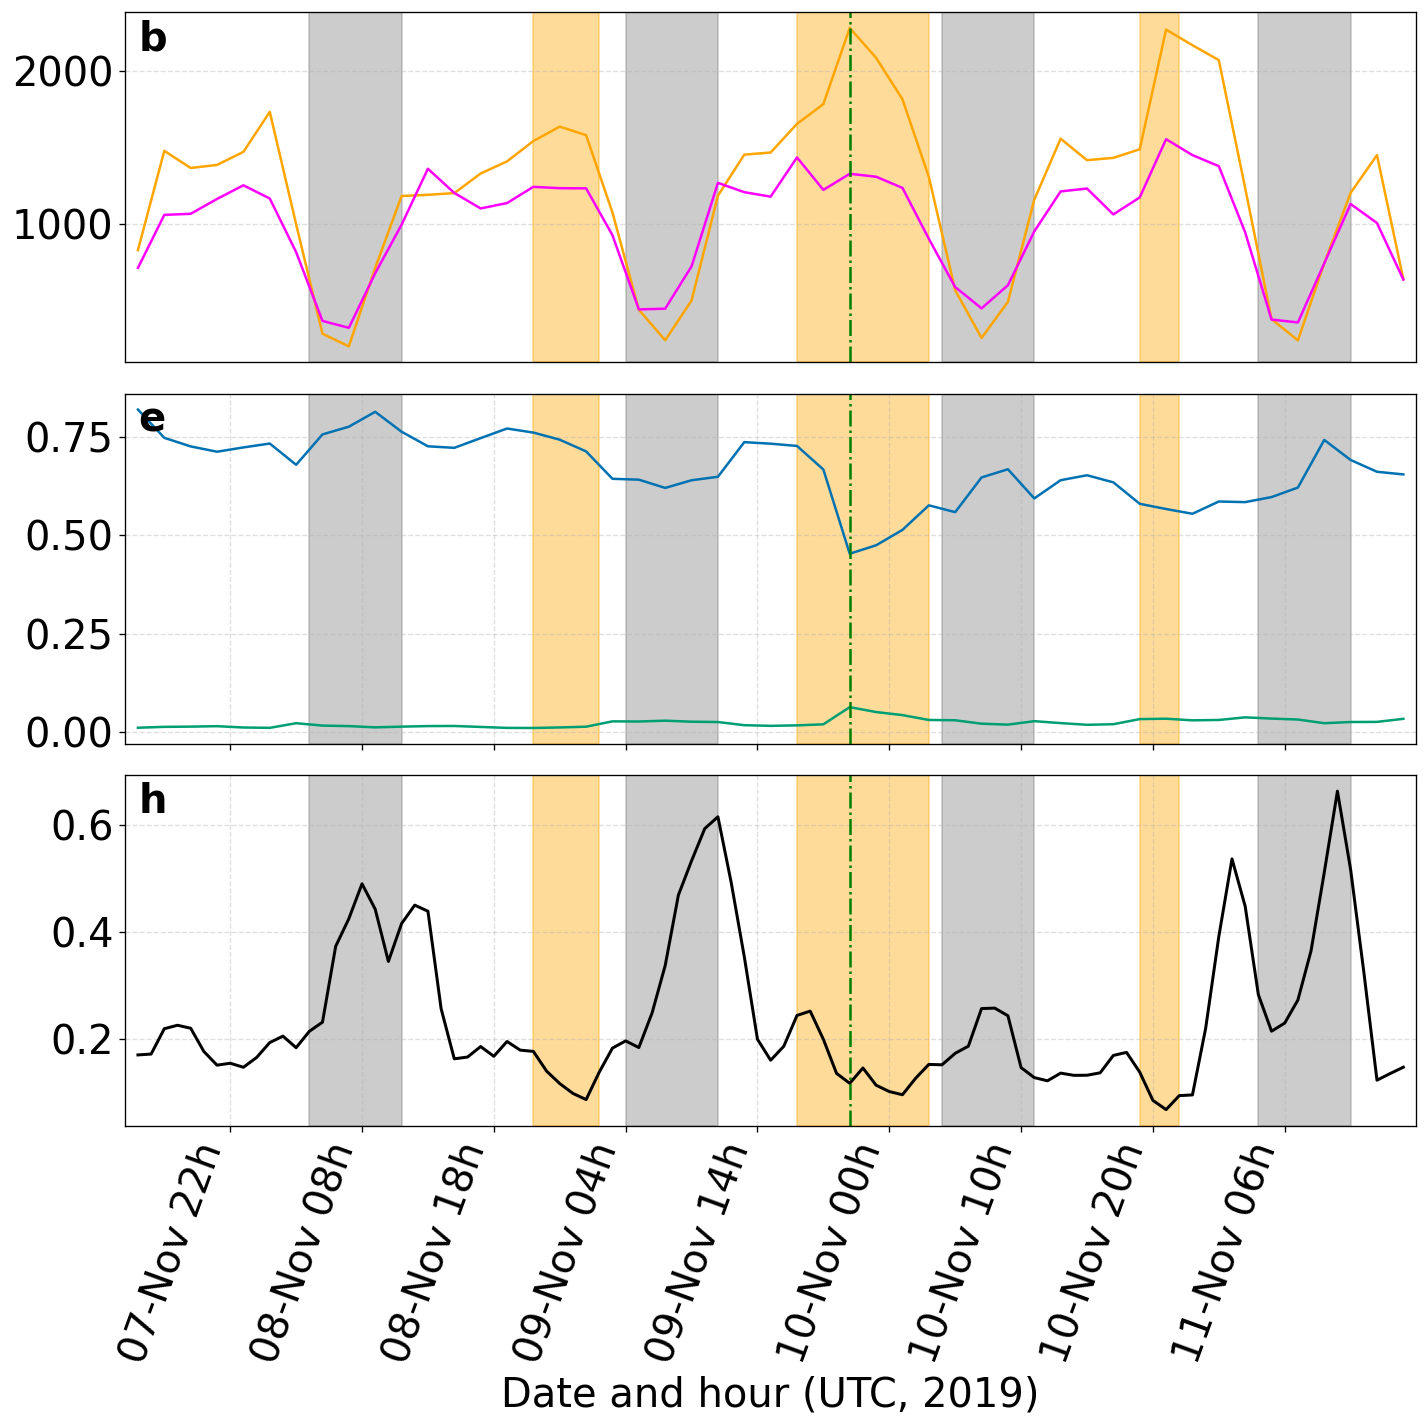

In [9]:

N = 3  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/9n/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/9n/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

df = df.rename(columns={r"$\epsilon_{\ccdf}$": "eps_ccdf", r"$\epsilon_{\knn}$": "eps_knn", r"$\epsilon_{\cco}$": "eps_cco"})


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
    raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
    "ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
    "knn":  r"$\epsilon_{\mathrm{knn}}$",
    "cco":  r"$\epsilon_{\mathrm{cco}}$",
    "max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 12), dpi=120)
df_9n = read_data("9n", datasets_folder=datasets_folder)

hour_9n = np.sort(df_9n["hour"].unique())[::hour_window_9n]

num_users_9n, num_hashtags_9n = get_num_users_hashtags(df_9n, hour_window=hour_window_9n)
plot_num_users_hashtags(axes[0], hour_9n, hour_window_9n, num_users_9n, num_hashtags_9n, title=None, inicio=0, final=140, legend=False)


hour_sort_9n_h, mod_sort_9n_h, nest_sort_9n_h = get_mod_nest_coefficient("9n", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)
#plot_mod_nestedness(axes[2], hour_9n, hour_window_9n, mod_sort_9n_h, nest_sort_9n_h, inicio=0, final=140, legend=False, tick_split=30, HORA_CRITICA=None)


hour_sort_9n_b, mod_sort_9n_b, nest_sort_9n_b = get_mod_nest_coefficient("9n", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)
plot_mod_nestedness(axes[1], hour_9n, hour_window_9n, mod_sort_9n_b, nest_sort_9n_b, inicio=0, final=140, legend=False, tick_split=30, HORA_CRITICA=None)

def rolling_mean_centrada(series):
    s = pd.to_numeric(series, errors="coerce")
    # Promedia [i-1, i, i+1]; en bordes usa los disponibles
    return s.rolling(window=3, center=True, min_periods=1).mean()

def plot_ma_if_exists(ycol, label):
	if ycol is not None and ycol in df:
		#y_ma = rolling_mean(df[ycol], N)
		y_ma = rolling_mean_centrada(df[ycol])
		axes[2].plot(
			x, y_ma,
			marker=None,            # no puntos: solo la media móvil
			linewidth=1.8,
			label=f"{label} (MA{N})",
            c="black"
		)
plot_ma_if_exists(cco_col, labels["cco"])
letras = ["b", "e", "h"]
for i, ax in enumerate(axes):
	if i == 0:
		ax.axvline(int(HORA_CRITICA_9N), linestyle="-.", color="green", label=f"CTW 9N\n{dt.datetime.utcfromtimestamp(int(HORA_CRITICA_9N)*3600).strftime('%Y/%m/%d %Hh')}")
	else:
	 	ax.axvline(int(HORA_CRITICA_9N), linestyle="-.", color="green")

	#ax.set_ylabel(r"$\epsilon$")
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)      
		
	#from 00:01 to 8:00
	ax.axvspan(436996, 437003, color='gray', alpha=0.4)
	#ax.axvspan(436996, 437003, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(437020, 437027, color='gray', alpha=0.4)
	ax.axvspan(437044, 437051, color='gray', alpha=0.4)
	ax.axvspan(437068, 437075, color='gray', alpha=0.4)
	ax.axvspan(437033, 437043, color='orange', alpha=0.4)
	#ax.axvspan(437033, 437043, color='orange', alpha=0.4, label="Candidates time windows")
	ax.axvspan(437059, 437062, color='orange', alpha=0.4)
	ax.axvspan(437013, 437018, color='orange', alpha=0.4)

	ax.tick_params(axis='both', which='major', labelsize=24)  
	#ax.legend()
	ax.text(
			0.01, 0.98, letras[i],            # posición (x,y) en coordenadas del eje
			transform=ax.transAxes,          # 0–1 relativo al eje
			fontsize=24,
			fontweight="bold",
			va="top",
			ha="left"
		)
    

#axes[0].set_title(f"9N ε metrics by Network — Media móvil (N={N})")
# Eje X menos cargado
#axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
#axes[3].set_xlabel("Date")
#axes[2].set_title("Modularity and Nestedness (Hashtags)")
#axes[3].set_title("Modularity and Nestedness (Bipartite)")
def horas_a_fecha(x_val, pos):
	# x_val es el número en el eje
	fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
	return fecha.strftime('%d-%b %Hh')
	#return fecha.strftime('%Y/%m/%d %Hh')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
axes[2].set_xlabel('Date and hour (UTC, 2019)', fontsize=24)
# Eje X menos cargado
axes[2].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[2].get_xticklabels():
	tick.set_rotation(70)
	tick.set_ha("right")





plt.tight_layout()
plt.show()


### Unipartite

Calculando el anidamiento y modularidad de 9n con criterio: h


100%|██████████| 49/49 [00:00<00:00, 723665.13it/s]


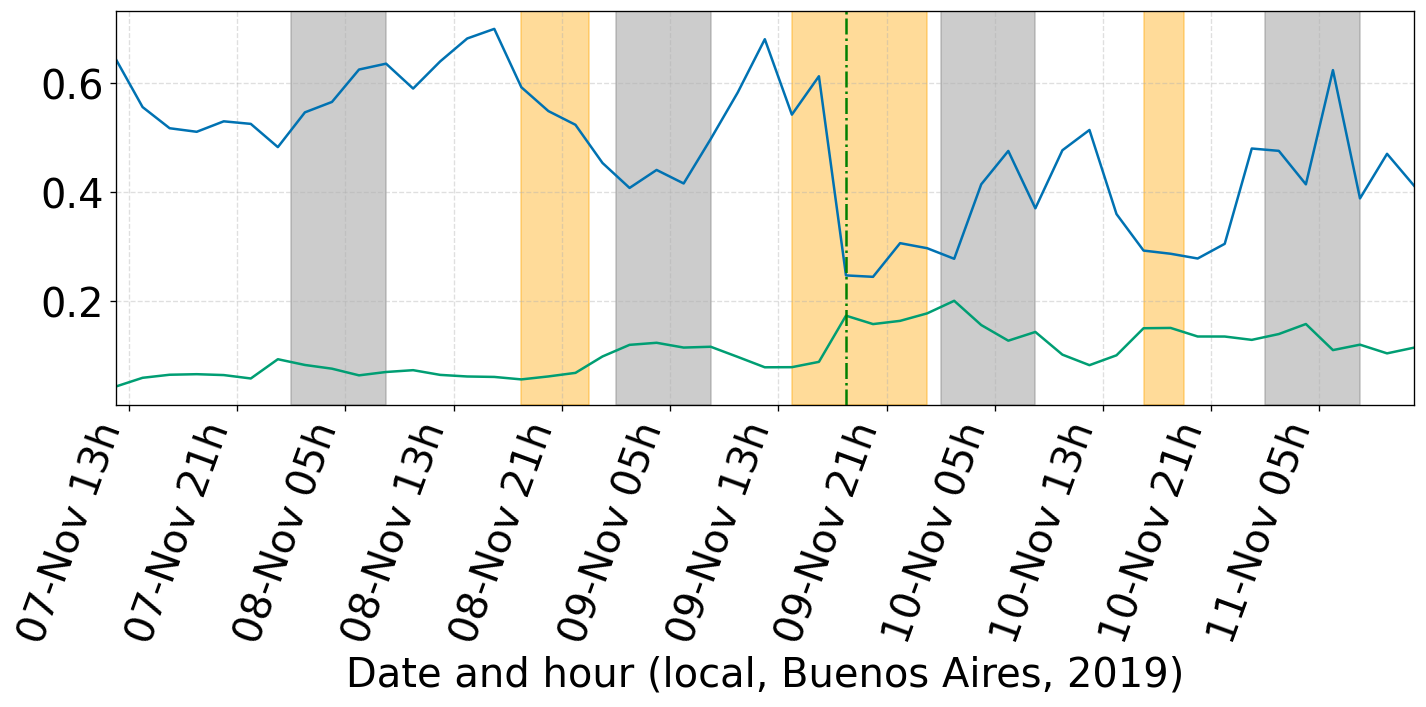

In [10]:

N = 3  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/9n/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/9n/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

df = df.rename(columns={r"$\epsilon_{\ccdf}$": "eps_ccdf", r"$\epsilon_{\knn}$": "eps_knn", r"$\epsilon_{\cco}$": "eps_cco"})


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
    raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
    "ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
    "knn":  r"$\epsilon_{\mathrm{knn}}$",
    "cco":  r"$\epsilon_{\mathrm{cco}}$",
    "max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(1, 1, sharex=True, figsize=(12, 6), dpi=120)
df_9n = read_data("9n", datasets_folder=datasets_folder)

hour_9n = np.sort(df_9n["hour"].unique())[::hour_window_9n]


hour_sort_9n_h, mod_sort_9n_h, nest_sort_9n_h = get_mod_nest_coefficient("9n", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)
plot_mod_nestedness(axes, hour_9n, hour_window_9n, mod_sort_9n_h, nest_sort_9n_h, inicio=0, final=len(hour_9n)*hour_window_9n, legend=False, tick_split=30, HORA_CRITICA=None)



axes.axvline(int(HORA_CRITICA_9N), linestyle="-.", color="green", label=f"CTW 9N\n{hour_to_local(int(HORA_CRITICA_9N), '9n').strftime('%Y/%m/%d %Hh')}")


#ax.set_ylabel(r"$\epsilon$")
axes.grid(True, linestyle="--", alpha=0.4)
axes.margins(x=0.01)      
	
#from 00:01 to 8:00
axes.axvspan(436996, 437003, color='gray', alpha=0.4)
#ax.axvspan(436996, 437003, color='gray', alpha=0.4, label="Low activity hours")
axes.axvspan(437020, 437027, color='gray', alpha=0.4)
axes.axvspan(437044, 437051, color='gray', alpha=0.4)
axes.axvspan(437068, 437075, color='gray', alpha=0.4)
axes.axvspan(437033, 437043, color='orange', alpha=0.4)
#ax.axvspan(437033, 437043, color='orange', alpha=0.4, label="Candidates time windows")
axes.axvspan(437059, 437062, color='orange', alpha=0.4)
axes.axvspan(437013, 437018, color='orange', alpha=0.4)

axes.tick_params(axis='both', which='major', labelsize=24)  
	#ax.legend()
    

#axes[0].set_title(f"9N ε metrics by Network — Media móvil (N={N})")
# Eje X menos cargado
#axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
#axes[3].set_xlabel("Date")
#axes[2].set_title("Modularity and Nestedness (Hashtags)")
#axes[3].set_title("Modularity and Nestedness (Bipartite)")
# Eje X en hora local (Buenos Aires)
horas_a_fecha = make_horas_a_fecha_local("9n")
axes.xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
axes.set_xlabel(local_xlabel("9n"), fontsize=24)
# Eje X menos cargado
axes.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes.get_xticklabels():
	tick.set_rotation(70)
	tick.set_ha("right")





# Límites X relativos a la CTW: −54 h … +42 h
apply_xlim_relative_ctw(axes, "9n")
plt.tight_layout()
plt.show()


### Epsilon

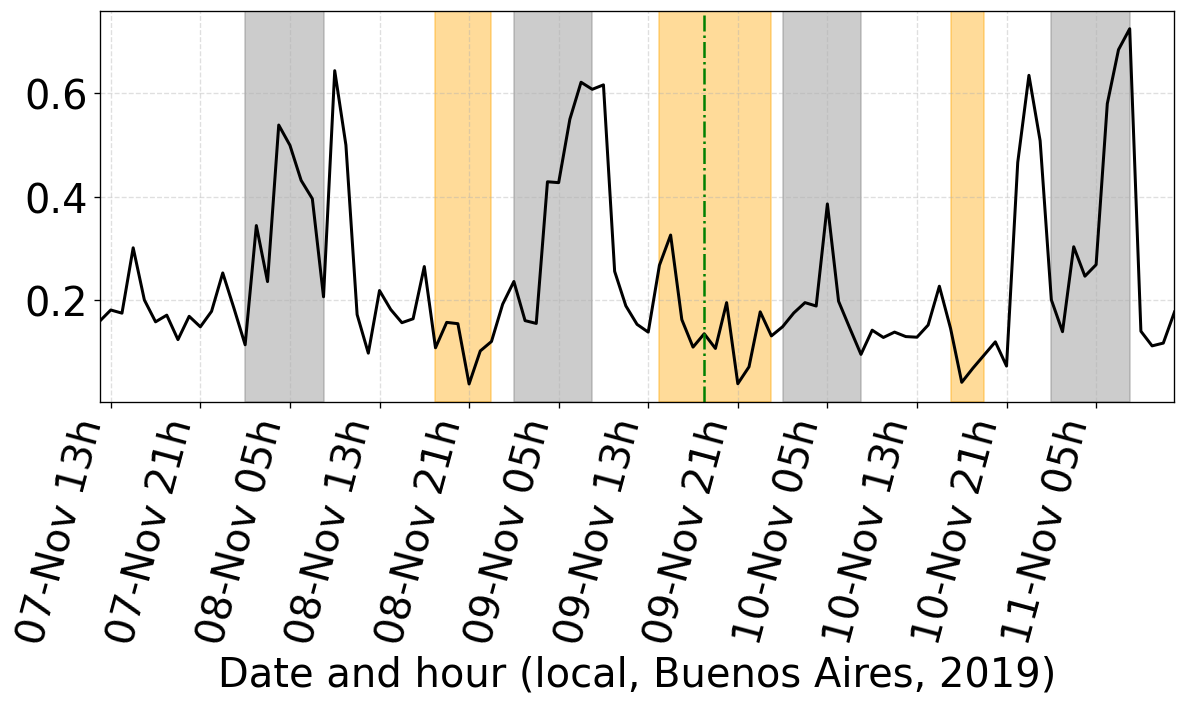

In [11]:

N = 1  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/9n/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/9n/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

df = df.rename(columns={r"$\epsilon_{\ccdf}$": "eps_ccdf", r"$\epsilon_{\knn}$": "eps_knn", r"$\epsilon_{\cco}$": "eps_cco"})


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
    raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
    "ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
    "knn":  r"$\epsilon_{\mathrm{knn}}$",
    "cco":  r"$\epsilon_{\mathrm{cco}}$",
    "max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(1, 1, sharex=True, figsize=(10, 6), dpi=120)
axes = [axes]
df_9n = read_data("9n", datasets_folder=datasets_folder)

hour_9n = np.sort(df_9n["hour"].unique())[::hour_window_9n]


def plot_ma_if_exists(ycol, label):
	if ycol is not None and ycol in df:
		y_ma = rolling_mean(df[ycol], N)
		#y_ma = rolling_mean_centrada(df[ycol])
		axes[0].plot(
			x, y_ma,
			marker=None,            # no puntos: solo la media móvil
			linewidth=1.8,
			label=f"{label}",
            c="black"
		)
plot_ma_if_exists(cco_col, labels["cco"])

for i, ax in enumerate(axes):
	if i < 0:
		ax.axvline(int(HORA_CRITICA_9N), linestyle="-.", color="green", label=f"CTW 9N\n{hour_to_local(int(HORA_CRITICA_9N), '9n').strftime('%Y/%m/%d %Hh')}")
	else:
	 	ax.axvline(int(HORA_CRITICA_9N), linestyle="-.", color="green")

	ax.set_ylabel(r"$\epsilon$")
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)      
		
	#from 00:01 to 8:00
	ax.axvspan(436996, 437003, color='gray', alpha=0.4)
	#ax.axvspan(436996, 437003, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(437020, 437027, color='gray', alpha=0.4)
	ax.axvspan(437044, 437051, color='gray', alpha=0.4)
	ax.axvspan(437068, 437075, color='gray', alpha=0.4)
	ax.axvspan(437033, 437043, color='orange', alpha=0.4)
	#ax.axvspan(437033, 437043, color='orange', alpha=0.4, label="Candidates time windows")
	ax.axvspan(437059, 437062, color='orange', alpha=0.4)
	ax.axvspan(437013, 437018, color='orange', alpha=0.4)
	#ax.legend(fontsize=18)

	ax.tick_params(axis='both', which='major', labelsize=24)  
    
#fig.suptitle("9N")
#axes[0].set_title(f"ε metrics by Network — Media móvil (N={N})")
# Eje X menos cargado
#axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
#axes[1].set_xlabel("Date")


# Eje X en hora local (Buenos Aires)
horas_a_fecha = make_horas_a_fecha_local("9n")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
axes[0].set_xlabel(local_xlabel("9n"), fontsize=24)
# Eje X menos cargado
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[0].get_xticklabels():
    tick.set_rotation(75)
    tick.set_ha("right")




# Límites X relativos a la CTW: −54 h … +42 h
apply_xlim_relative_ctw(axes[0], "9n")
plt.tight_layout()
plt.show()


## Charlie Hebdo

In [12]:
otras_horas_ch = [str(hor) for hor in range(int(HORA_CRITICA_CH)-48, int(HORA_CRITICA_CH)+48)]
registros = []  # aquí acumulamos las filas (hora, clave_max)

for i in otras_horas_ch:
	source_path = f"graphs/nodes_hashtag/ch/{hour_window_ch}/{i}.gexf"
	out_path =  f"epsilon_sq/ch/{i}/{i}.edge"
	if not os.path.exists(f"./epsilon_sq/ch/{i}/"):
		os.makedirs(f"./epsilon_sq/ch/{i}/")
	if os.path.exists(source_path):
		gexf_a_edge(source_path, out_path)    
		# Diccionario y clave con máximo valor
		d = get_dict_hora_kt("ch", i, hour_window=hour_window_ch)
		clave_max = max(d, key=d.get) if d else None  # None si el dict está vacío

		# Guardar registro
		registros.append({"hora": i, "clave_max": clave_max})

# Construir DataFrame final (dos columnas)
df_max = pd.DataFrame(registros, columns=["hora", "clave_max"])
df_max.to_csv("./epsilon_sq/ch/kts.csv")


 16%|█▌        | 32/200 [00:00<00:00, 5056.81it/s]


### All

Calculando el anidamiento y modularidad de ch con criterio: h


100%|██████████| 252/252 [00:00<00:00, 1262801.20it/s]


Calculando el anidamiento y modularidad de ch con criterio: b


100%|██████████| 252/252 [00:00<00:00, 1457882.22it/s]
/tmp/ipykernel_196319/2166180687.py:118: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


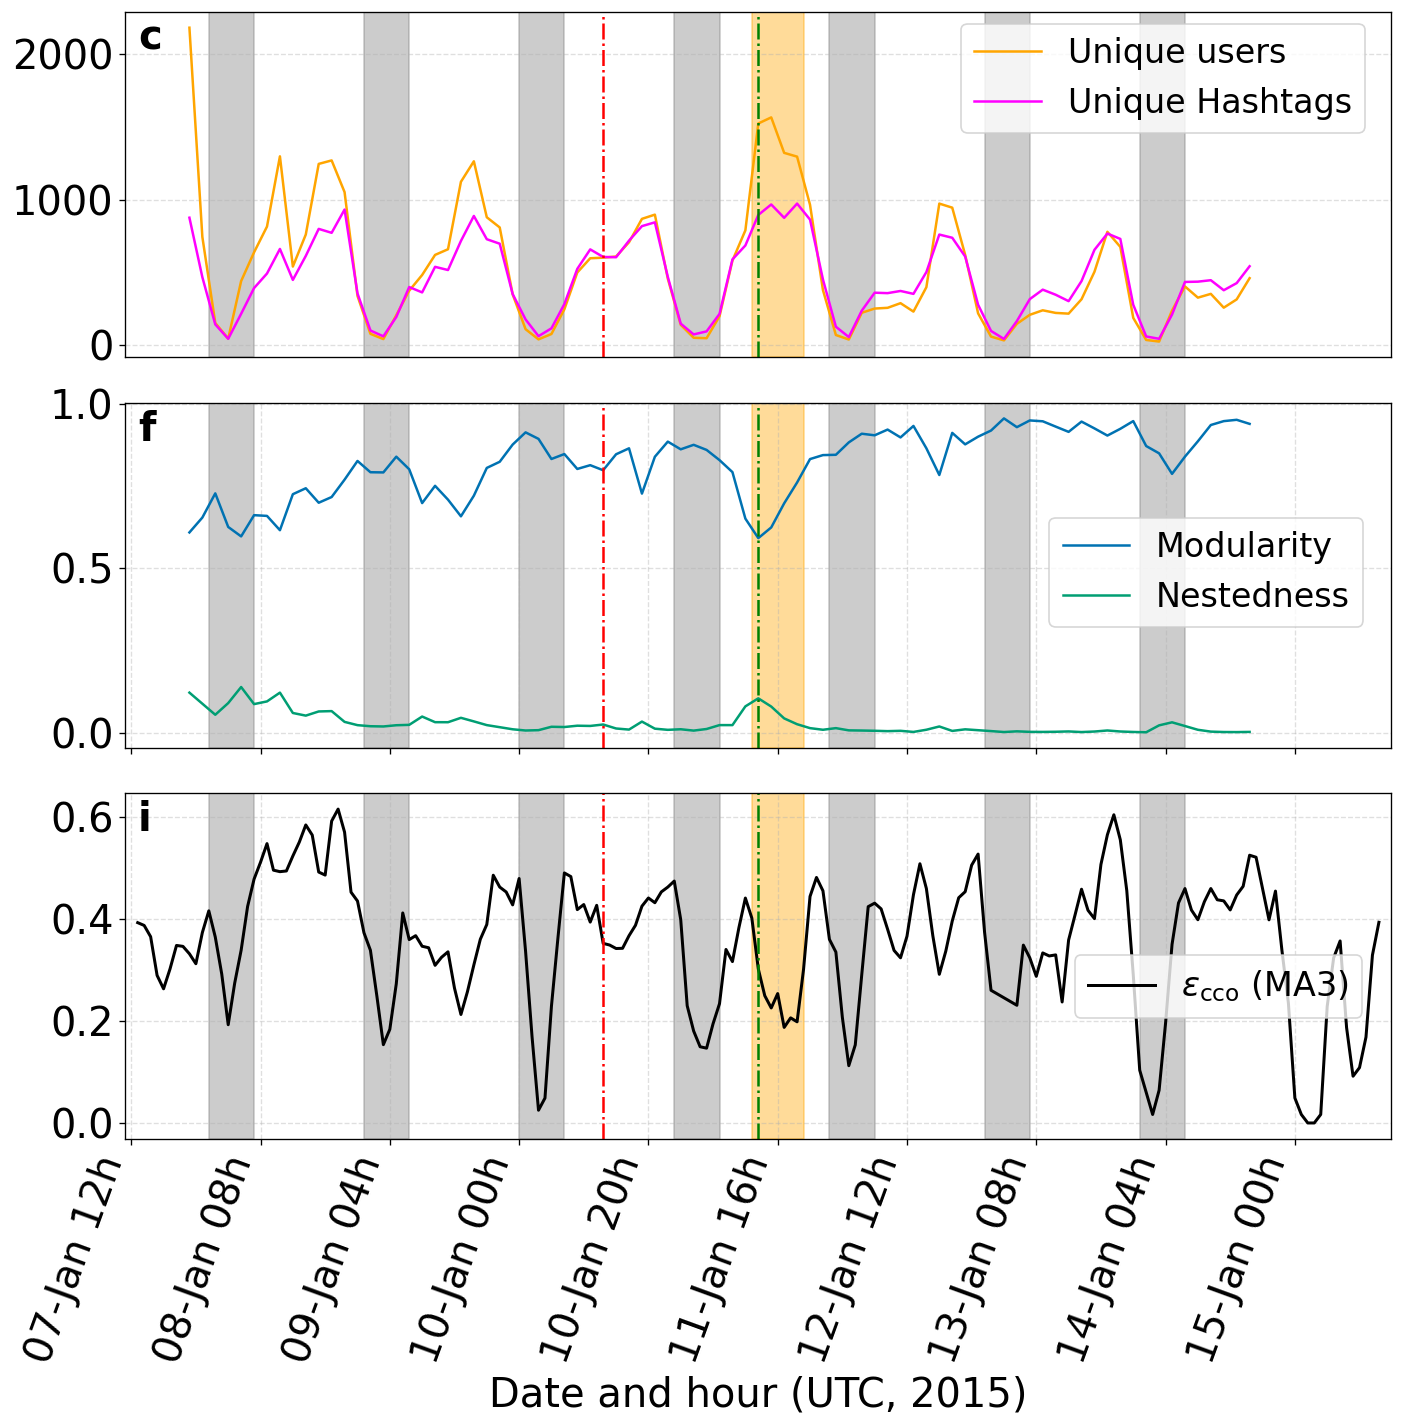

In [13]:

N = 3  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/ch/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/ch/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

df = df.rename(columns={r"$\epsilon_{\ccdf}$": "eps_ccdf", r"$\epsilon_{\knn}$": "eps_knn", r"$\epsilon_{\cco}$": "eps_cco"})


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
	raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
	"ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
	"knn":  r"$\epsilon_{\mathrm{knn}}$",
	"cco":  r"$\epsilon_{\mathrm{cco}}$",
	"max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 12), dpi=120)


df_ch = read_data("ch", datasets_folder=datasets_folder)

hour_ch = np.sort(df_ch["hour"].unique())[::hour_window_ch]


num_users_ch, num_hashtags_ch = get_num_users_hashtags(df_ch, hour_window=hour_window_ch)
plot_num_users_hashtags(axes[0], hour_ch, hour_window_ch, num_users_ch, num_hashtags_ch, title=None, inicio=166, final=333, legend=False)


hour_sort_ch_h, mod_sort_ch_h, nest_sort_ch_h = get_mod_nest_coefficient("ch", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)
#plot_mod_nestedness(axes[2], hour_ch, hour_window_ch, mod_sort_ch_h, nest_sort_ch_h, inicio=206, final=293, legend=False, tick_split=30, HORA_CRITICA=None)


hour_sort_ch_b, mod_sort_ch_b, nest_sort_ch_b = get_mod_nest_coefficient("ch", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)
plot_mod_nestedness(axes[1], hour_ch, hour_window_ch, mod_sort_ch_b, nest_sort_ch_b, inicio=166, final=333, legend=False, tick_split=30, HORA_CRITICA=None)



def plot_ma_if_exists(ycol, label):
	if ycol is not None and ycol in df:
		#y_ma = rolling_mean(df[ycol], N)
		y_ma = rolling_mean_centrada(df[ycol])
		axes[2].plot(
			x, y_ma,
			marker=None,            # no puntos: solo la media móvil
			linewidth=1.8,
			label=f"{label} (MA{N})",
            c="black"
		)
plot_ma_if_exists(cco_col, labels["cco"])
letras = ["c", "f", "i"]
for i, ax in enumerate(axes):
	ax.axvline(int(HORA_CRITICA_CH), linestyle="-.", color="green")
	ax.axvline(int(HORA_CRITICA_CH)-24, linestyle="-.", color="red")
	#ax.axvline(int(HORA_CRITICA_CH)-48, linestyle="-.", color="red")
	#ax.axvline(int(HORA_CRITICA_CH)-72, linestyle="-.", color="red")

	#ax.axvline(int(HORA_CRITICA_CH)+24, linestyle="-.", color="red")
	#ax.axvline(int(HORA_CRITICA_CH)+48, linestyle="-.", color="red")
	#ax.axvline(int(HORA_CRITICA_CH)+72, linestyle="-.", color="red")

	#ax.set_ylabel(r"$\epsilon$")
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)
	ax.axvspan(394632, 394639, color='gray', alpha=0.4)
	ax.axvspan(394656, 394663, color='gray', alpha=0.4)
	ax.axvspan(394680, 394687, color='gray', alpha=0.4)
	#ax.axvspan(394680, 394687, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(394704, 394711, color='gray', alpha=0.4)
	ax.axvspan(394728, 394735, color='gray', alpha=0.4)
	ax.axvspan(394752, 394759, color='gray', alpha=0.4)
	ax.axvspan(394776, 394783, color='gray', alpha=0.4)
	
	ax.axvspan(394716, 394724, color='orange', alpha=0.4)
	#ax.axvspan(394744, 394746, color='orange', alpha=0.4)
	#ax.axvspan(394716, 394724, color='orange', alpha=0.4, label="Candidates time windows")
	#ax.legend()



	ax.tick_params(axis='both', which='major', labelsize=24)  
	ax.text(
			0.01, 0.98, letras[i],            # posición (x,y) en coordenadas del eje
			transform=ax.transAxes,          # 0–1 relativo al eje
			fontsize=24,
			fontweight="bold",
			va="top",
			ha="left"
		)

#axes[0].set_title(f"Charlie Hebdo ε metrics by Network — Media móvil (N={N})")
#axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
#axes[3].set_xlabel("Date")
#axes[2].set_title("Modularity and Nestedness (Hashtags)")
#axes[3].set_title("Modularityand Nestedness (Bipartite)")

axes[0].legend(loc=[0.66, 0.65], fontsize=20)
axes[1].legend(loc=[0.73, 0.35], fontsize=20)
axes[2].legend(loc=[0.75, 0.35], fontsize=20)

def horas_a_fecha(x_val, pos):
	# x_val es el número en el eje
	fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
	return fecha.strftime('%d-%b %Hh')
	#return fecha.strftime('%Y/%m/%d %Hh')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
axes[2].set_xlabel('Date and hour (UTC, 2015)', fontsize=24)
# Eje X menos cargado
axes[2].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[2].get_xticklabels():
	tick.set_rotation(70)
	tick.set_ha("right")


plt.tight_layout()
plt.show()


### Unipartite

Calculando el anidamiento y modularidad de ch con criterio: h


100%|██████████| 252/252 [00:00<00:00, 1480342.59it/s]


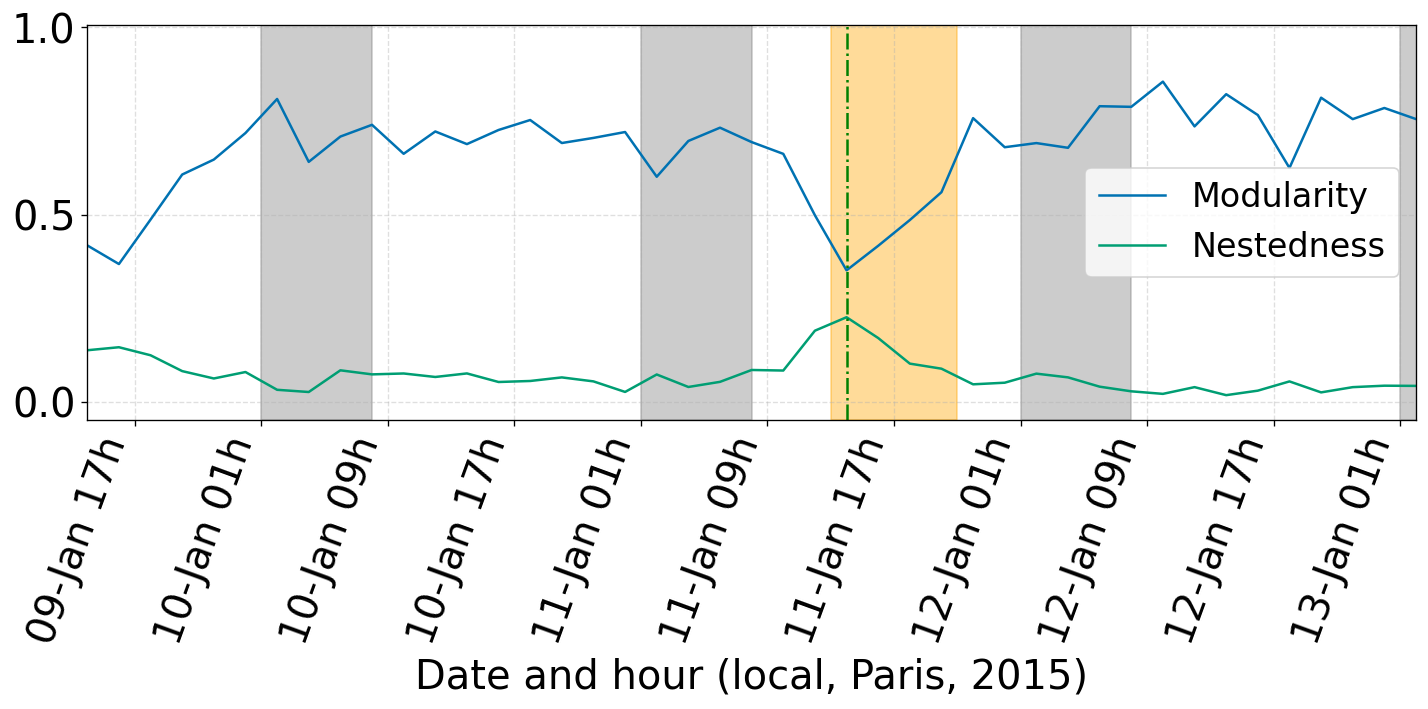

In [14]:

N = 3  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/ch/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/ch/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

df = df.rename(columns={r"$\epsilon_{\ccdf}$": "eps_ccdf", r"$\epsilon_{\knn}$": "eps_knn", r"$\epsilon_{\cco}$": "eps_cco"})


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
	raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
	"ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
	"knn":  r"$\epsilon_{\mathrm{knn}}$",
	"cco":  r"$\epsilon_{\mathrm{cco}}$",
	"max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(1, 1, sharex=True, figsize=(12, 6), dpi=120)


df_ch = read_data("ch", datasets_folder=datasets_folder)

hour_ch = np.sort(df_ch["hour"].unique())[::hour_window_ch]



hour_sort_ch_h, mod_sort_ch_h, nest_sort_ch_h = get_mod_nest_coefficient("ch", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)
plot_mod_nestedness(axes, hour_ch, hour_window_ch, mod_sort_ch_h, nest_sort_ch_h, inicio=0, final=len(hour_ch)*hour_window_ch, legend=False, tick_split=30, HORA_CRITICA=None)




axes.axvline(int(HORA_CRITICA_CH), linestyle="-.", color="green")
#ax.set_ylabel(r"$\epsilon$")
axes.grid(True, linestyle="--", alpha=0.4)
axes.margins(x=0.01)
axes.axvspan(394680, 394687, color='gray', alpha=0.4)
#ax.axvspan(394680, 394687, color='gray', alpha=0.4, label="Low activity hours")
axes.axvspan(394704, 394711, color='gray', alpha=0.4)
axes.axvspan(394728, 394735, color='gray', alpha=0.4)
axes.axvspan(394752, 394754, color='gray', alpha=0.4)

axes.axvspan(394716, 394724, color='orange', alpha=0.4)
#axes.axvspan(394744, 394746, color='orange', alpha=0.4)

#ax.axvspan(394716, 394724, color='orange', alpha=0.4, label="Candidates time windows")
axes.legend(loc=loc_legend, fontsize=20)

axes.tick_params(axis='both', which='major', labelsize=24)  

#axes[0].set_title(f"Charlie Hebdo ε metrics by Network — Media móvil (N={N})")
#axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
#axes[3].set_xlabel("Date")
#axes[2].set_title("Modularity and Nestedness (Hashtags)")
#axes[3].set_title("Modularity and Nestedness (Bipartite)")
# Eje X en hora local (Paris)
horas_a_fecha = make_horas_a_fecha_local("ch")
axes.xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
axes.set_xlabel(local_xlabel("ch"), fontsize=24)
# Eje X menos cargado
axes.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes.get_xticklabels():
	tick.set_rotation(70)
	tick.set_ha("right")


# Límites X relativos a la CTW: −48 h … +36 h
apply_xlim_relative_ctw(axes, "ch")
plt.tight_layout()
plt.show()


### Epsilon

Calculando el anidamiento y modularidad de ch con criterio: b


100%|██████████| 252/252 [00:00<00:00, 975959.93it/s]


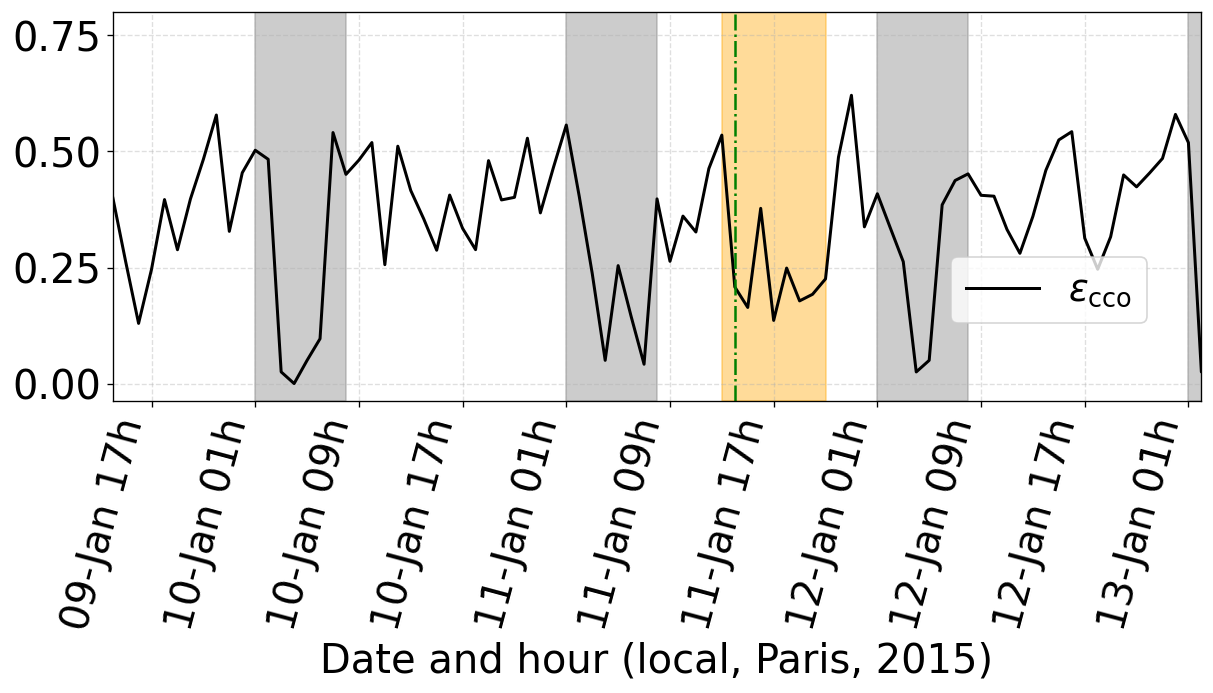

In [15]:

N = 1  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/ch/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/ch/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

df = df.rename(columns={r"$\epsilon_{\ccdf}$": "eps_ccdf", r"$\epsilon_{\knn}$": "eps_knn", r"$\epsilon_{\cco}$": "eps_cco"})


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
	raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
	"ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
	"knn":  r"$\epsilon_{\mathrm{knn}}$",
	"cco":  r"$\epsilon_{\mathrm{cco}}$",
	"max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(1, 1, sharex=True, figsize=(10, 6), dpi=120)
axes = [axes]

df_ch = read_data("ch", datasets_folder=datasets_folder)

hour_ch = np.sort(df_ch["hour"].unique())[::hour_window_ch]


hour_sort_ch_b, mod_sort_ch_b, nest_sort_ch_b = get_mod_nest_coefficient("ch", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)

def plot_ma_if_exists(ycol, label):
	if ycol is not None and ycol in df:
		y_ma = rolling_mean(df[ycol], N)
		#y_ma = rolling_mean_centrada(df[ycol])
		axes[0].plot(
			x, y_ma,
			marker=None,            # no puntos: solo la media móvil
			linewidth=1.8,
			label=f"{label}",
            c="black"
		)
plot_ma_if_exists(cco_col, labels["cco"])

for i, ax in enumerate(axes):
	ax.axvline(int(HORA_CRITICA_CH), linestyle="-.", color="green")

	#ax.set_ylabel(r"$\epsilon$")
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)
	ax.axvspan(394680, 394687, color='gray', alpha=0.4)
	#ax.axvspan(394680, 394687, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(394704, 394711, color='gray', alpha=0.4)
	ax.axvspan(394728, 394735, color='gray', alpha=0.4)
	ax.axvspan(394752, 394754, color='gray', alpha=0.4)
	
	ax.axvspan(394716, 394724, color='orange', alpha=0.4)
	#ax.axvspan(394744, 394746, color='orange', alpha=0.4)
	#ax.axvspan(394716, 394724, color='orange', alpha=0.4, label="Candidates time windows")
	ax.legend(loc=[0.77, 0.2], fontsize=22)

	ax.tick_params(axis='both', which='major', labelsize=24)  
#axes[0].set_title(f"Charlie Hebdo ε metrics by Network — Media móvil (N={N})")
#axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
#axes[1].set_xlabel("Date")
#axes[1].set_title("Modularity and Nestedness (Bipartite)")


# Eje X en hora local (Paris)
horas_a_fecha = make_horas_a_fecha_local("ch")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
axes[0].set_xlabel(local_xlabel("ch"), fontsize=24)
# Eje X menos cargado
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[0].get_xticklabels():
	tick.set_rotation(75)
	tick.set_ha("right")


# Límites X relativos a la CTW: −48 h … +36 h
apply_xlim_relative_ctw(axes[0], "ch")
plt.tight_layout()
plt.show()
